# Tesla Deliveries & Production — End-to-End ML Pipeline
**Dataset:** Tesla EA Deliveries and Production Data (2015–2025)  
**Source:** [Kaggle — nalisha/tesla-ea-deliveries-and-production-data20152025](https://www.kaggle.com/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025)  

**Pipeline stages covered:**
1. Data ingestion & preprocessing
2. Exploratory data analysis (EDA)
3. Feature engineering
4. Regression modeling & hyperparameter tuning
5. Time series forecasting (SARIMA, Prophet, LSTM)
6. Results & interpretation

---
## 0. Setup & Imports

In [1]:
# Core
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})

# Sklearn
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.pipeline import Pipeline

# Time series
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
import scipy.stats as stats

# Optional — install if needed
# !pip install prophet tensorflow

print('All imports OK.')

All imports OK.


---
## 1. Data Ingestion & Preprocessing

In [2]:
# ── Load dataset ──────────────────────────────────────────────────────────────
df_raw = pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')
print('Shape:', df_raw.shape)
print('Columns:', df_raw.columns.tolist())
df_raw.head(10)


Shape: (2640, 12)
Columns: ['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722
5,2020,4,Asia,Model X,4656,5043,86930.57,82,477,333.14,Official (Quarter),5798
6,2015,11,Asia,Model 3,7717,7976,87588.21,82,475,549.84,Interpolated (Month),9961
7,2020,6,Europe,Cybertruck,8410,9192,73815.61,100,592,746.81,Official (Quarter),8216
8,2022,4,Europe,Model S,15145,15760,69993.86,100,563,1279.00,Interpolated (Month),13264
9,2021,3,Middle East,Model Y,7790,8208,50591.60,82,485,566.72,Interpolated (Month),3383


In [3]:
# ── Aggregate monthly/regional rows into quarterly totals ─────────────────────
df = df_raw.copy()

# Create a quarter period from Year + Month
df['period'] = pd.PeriodIndex(
    pd.to_datetime(df[['Year', 'Month']].assign(day=1)), freq='Q'
)

# Sum deliveries and production by quarter (across all regions and models)
df_q = (
    df.groupby('period', as_index=False)
    .agg(
        deliveries=('Estimated_Deliveries', 'sum'),
        production=('Production_Units', 'sum'),
    )
    .sort_values('period')
    .reset_index(drop=True)
)

df_q['date'] = df_q['period'].dt.to_timestamp()
df_q.set_index('date', inplace=True)

# Use df_q as the working frame going forward
df = df_q
print('Quarterly shape:', df.shape)
df.head(10)


Quarterly shape: (44, 3)


,period,deliveries,production
date,,,
2015-01-01,2015Q1,532800,572063
2015-04-01,2015Q2,608674,652164
2015-07-01,2015Q3,580430,615982
2015-10-01,2015Q4,653363,705486
2016-01-01,2016Q1,600877,644507
2016-04-01,2016Q2,604613,645512
2016-07-01,2016Q3,626149,675422
2016-10-01,2016Q4,602442,651559
2017-01-01,2017Q1,571406,614261


In [4]:
# ── Columns are already standardised from aggregation step ───────────────────
print(f'Deliveries column: "deliveries"  |  Production column: "production"')
print('\nMissing values:')
print(df[['deliveries', 'production']].isnull().sum())
df[['deliveries', 'production']].describe()


Deliveries column: "deliveries"  |  Production column: "production"

Missing values:
deliveries    0
production    0
dtype: int64


,deliveries,production
count,44.000000,44.000000
mean,595331.977273,639350.840909
std,30699.517157,33001.251434
min,493949.000000,535298.000000
25%,581649.000000,624549.500000
50%,597294.000000,640926.500000
75%,613119.500000,658817.250000
max,655343.000000,705486.000000


In [5]:
# ── Impute missing values ─────────────────────────────────────────────────────
df['deliveries'] = df['deliveries'].interpolate(method='linear')
df['production'] = df['production'].interpolate(method='linear')

# ── Outlier detection (IQR + z-score) ────────────────────────────────────────
for col in ['deliveries', 'production']:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    z   = np.abs(stats.zscore(df[col].dropna()))
    iqr_flag = (df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)
    print(f'{col}: {iqr_flag.sum()} IQR outliers detected')

# ── Derived columns ───────────────────────────────────────────────────────────
df['gap'] = df['production'] - df['deliveries']

# Flag known anomaly: Q1 2023 price-cut impact
df['price_cut_flag'] = ((df.index.year == 2023) & (df.index.month <= 3)).astype(int)

print('\nCleaned dataset shape:', df.shape)
df[['deliveries', 'production', 'gap', 'price_cut_flag']].tail(8)


deliveries: 3 IQR outliers detected
production: 2 IQR outliers detected

Cleaned dataset shape: (44, 5)


,deliveries,production,gap,price_cut_flag
date,,,,
2024-01-01,625851,674384,48533,0
2024-04-01,588328,636098,47770,0
2024-07-01,595658,640902,45244,0
2024-10-01,597062,636280,39218,0
2025-01-01,591840,632795,40955,0
2025-04-01,582037,623978,41941,0
2025-07-01,609084,648448,39364,0
2025-10-01,585501,629295,43794,0


---
## 2. Exploratory Data Analysis

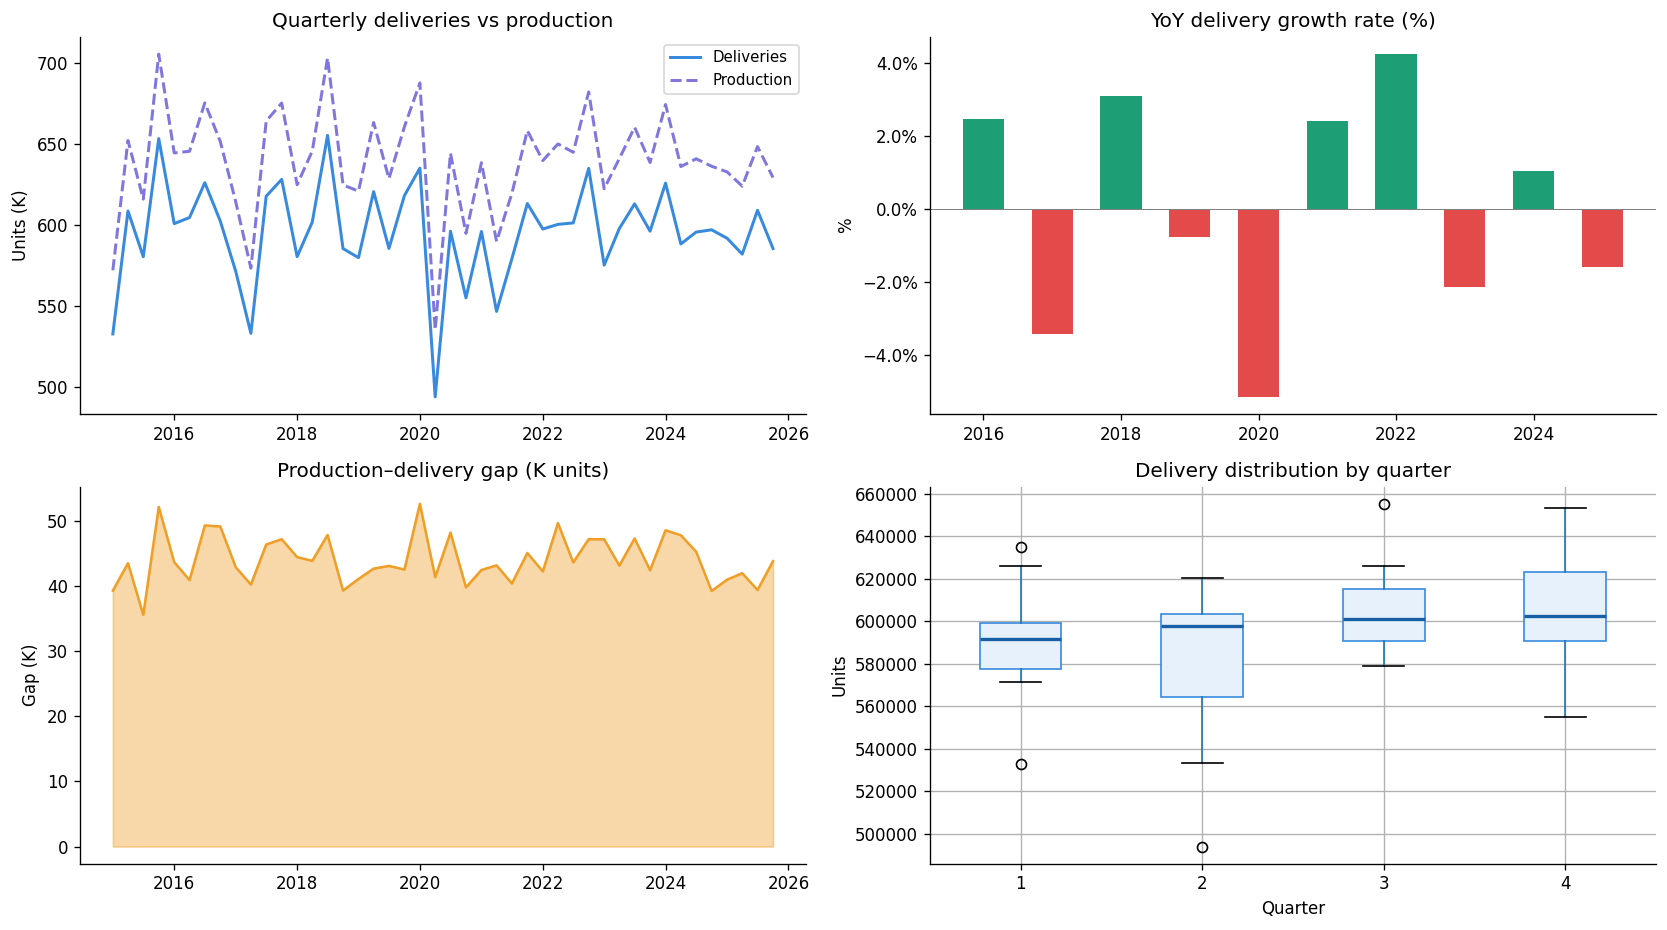

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Tesla Deliveries & Production — EDA Overview', fontsize=14, fontweight='bold')

# 1. Raw time series
ax = axes[0, 0]
ax.plot(df.index, df['deliveries'] / 1000, label='Deliveries', color='#378ADD', linewidth=1.8)
ax.plot(df.index, df['production'] / 1000, label='Production', color='#7F77DD', linewidth=1.8, linestyle='--')
ax.set_title('Quarterly deliveries vs production')
ax.set_ylabel('Units (K)')
ax.legend(fontsize=9)

# 2. YoY growth rate
ax = axes[0, 1]
annual = df['deliveries'].resample('YE').sum()
yoy    = annual.pct_change() * 100
colors = ['#E24B4A' if v < 0 else '#1D9E75' for v in yoy]
ax.bar(yoy.index.year, yoy.values, color=colors, width=0.6)
ax.axhline(0, color='gray', linewidth=0.6)
ax.set_title('YoY delivery growth rate (%)')
ax.set_ylabel('%')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())

# 3. Production–delivery gap
ax = axes[1, 0]
df['gap'] = df['production'] - df['deliveries']
ax.fill_between(df.index, df['gap'] / 1000, alpha=0.4, color='#EF9F27')
ax.plot(df.index, df['gap'] / 1000, color='#EF9F27', linewidth=1.5)
ax.set_title('Production–delivery gap (K units)')
ax.set_ylabel('Gap (K)')

# 4. Quarterly seasonality box plot
ax = axes[1, 1]
df['quarter'] = df.index.quarter
df.boxplot(column='deliveries', by='quarter', ax=ax, patch_artist=True,
           boxprops=dict(facecolor='#E6F1FB', color='#378ADD'),
           medianprops=dict(color='#185FA5', linewidth=2))
ax.set_title('Delivery distribution by quarter')
ax.set_xlabel('Quarter')
ax.set_ylabel('Units')
plt.suptitle('')

plt.tight_layout()
plt.savefig('eda_overview.png', bbox_inches='tight')
plt.show()

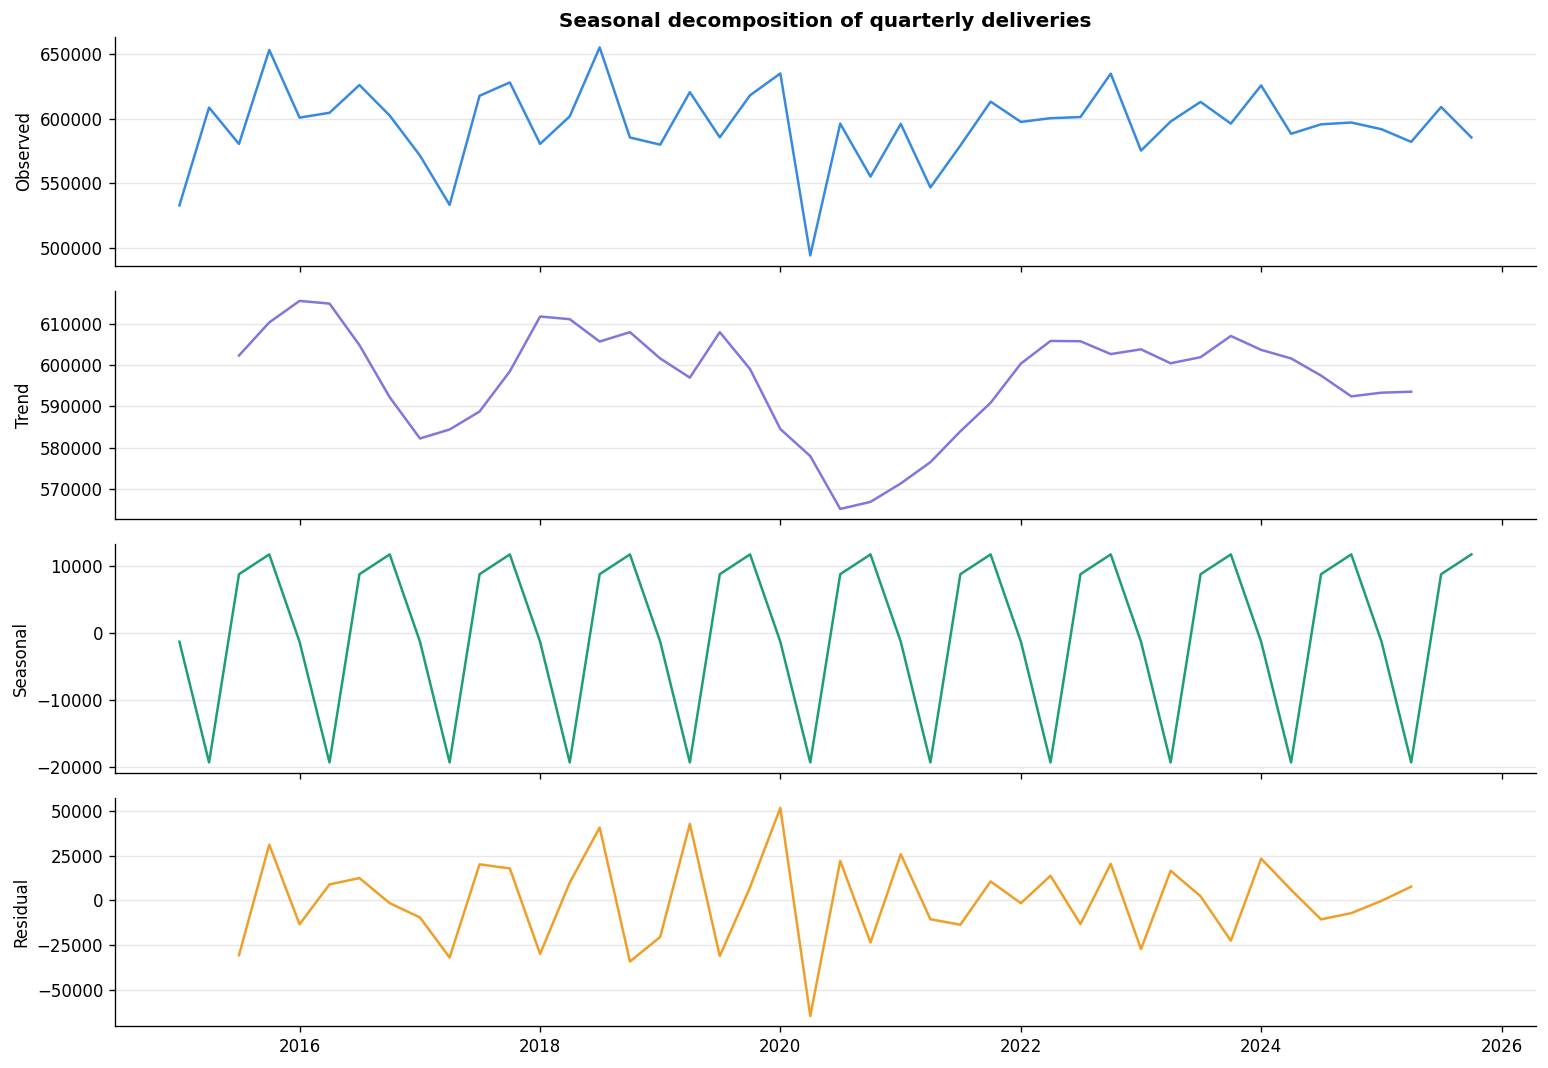

In [7]:
# ── Seasonal decomposition ────────────────────────────────────────────────────
decomp = seasonal_decompose(df['deliveries'].dropna(), model='additive', period=4)

fig, axes = plt.subplots(4, 1, figsize=(13, 9), sharex=True)
for ax, comp, title, color in zip(
    axes,
    [decomp.observed, decomp.trend, decomp.seasonal, decomp.resid],
    ['Observed', 'Trend', 'Seasonal', 'Residual'],
    ['#378ADD', '#7F77DD', '#1D9E75', '#EF9F27']
):
    ax.plot(comp, color=color, linewidth=1.5)
    ax.set_ylabel(title, fontsize=10)
    ax.grid(axis='y', alpha=0.3)

axes[0].set_title('Seasonal decomposition of quarterly deliveries', fontweight='bold')
plt.tight_layout()
plt.savefig('seasonal_decomposition.png', bbox_inches='tight')
plt.show()

In [8]:
# ── Stationarity tests ────────────────────────────────────────────────────────
def test_stationarity(series, name='series'):
    adf_res  = adfuller(series.dropna(), autolag='AIC')
    kpss_res = kpss(series.dropna(), regression='c', nlags='auto')
    print(f'─── {name} ───')
    print(f'  ADF  statistic: {adf_res[0]:.4f}  p-value: {adf_res[1]:.4f}  (H0: unit root)')
    print(f'  KPSS statistic: {kpss_res[0]:.4f}  p-value: {kpss_res[1]:.4f}  (H0: stationary)')
    conclusion = 'STATIONARY' if adf_res[1] < 0.05 and kpss_res[1] > 0.05 else 'NON-STATIONARY'
    print(f'  → {conclusion}\n')

test_stationarity(df['deliveries'], 'Deliveries (level)')
test_stationarity(df['deliveries'].diff().dropna(), 'Deliveries (1st diff)')

─── Deliveries (level) ───
  ADF  statistic: -7.7551  p-value: 0.0000  (H0: unit root)
  KPSS statistic: 0.0600  p-value: 0.1000  (H0: stationary)
  → STATIONARY

─── Deliveries (1st diff) ───
  ADF  statistic: -6.9697  p-value: 0.0000  (H0: unit root)
  KPSS statistic: 0.5000  p-value: 0.0417  (H0: stationary)
  → NON-STATIONARY



C:\Users\sayan\AppData\Local\Temp\ipykernel_32648\120207978.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_res = kpss(series.dropna(), regression='c', nlags='auto')


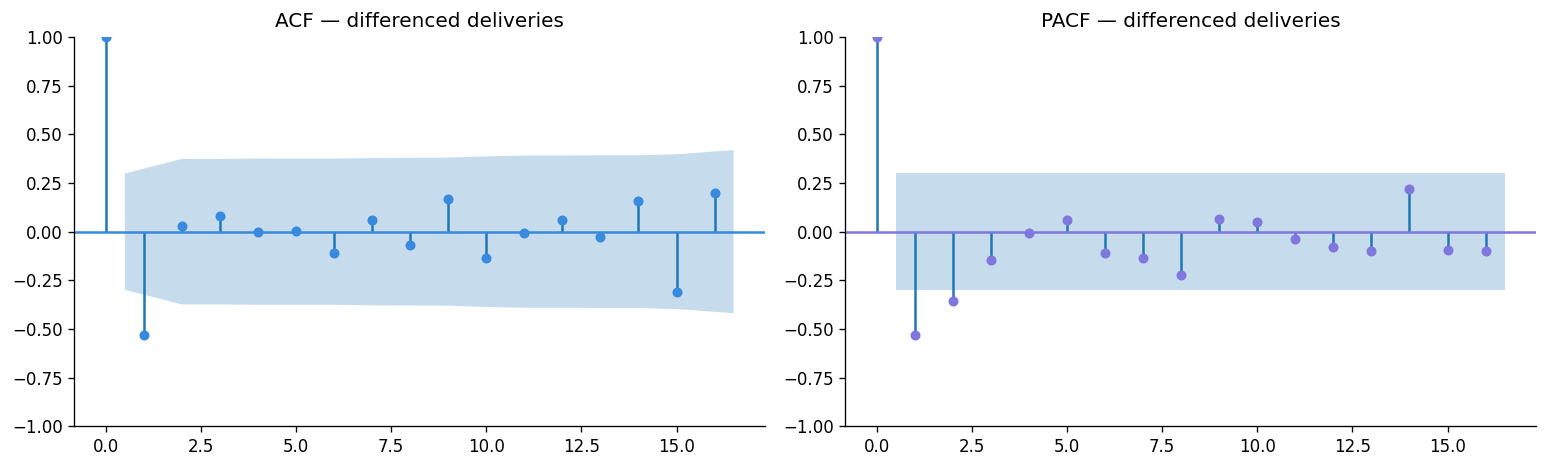

In [9]:
# ── ACF / PACF ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_acf(df['deliveries'].diff().dropna(),  lags=16, ax=axes[0], color='#378ADD')
plot_pacf(df['deliveries'].diff().dropna(), lags=16, ax=axes[1], color='#7F77DD')
axes[0].set_title('ACF — differenced deliveries')
axes[1].set_title('PACF — differenced deliveries')
plt.tight_layout()
plt.savefig('acf_pacf.png', bbox_inches='tight')
plt.show()

---
## 3. Feature Engineering

In [10]:
def build_features(df):
    f = df[['deliveries', 'production', 'gap', 'price_cut_flag']].copy()

    # ── Lag features ──────────────────────────────────────────────────────────
    f['deliv_lag1']      = f['deliveries'].shift(1)
    f['prod_lag1']       = f['production'].shift(1)
    f['gap_lag1']        = f['gap'].shift(1)
    f['deliv_lag4']      = f['deliveries'].shift(4)   # same quarter prior year

    # ── Rolling statistics ────────────────────────────────────────────────────
    f['roll_mean_4q']    = f['deliveries'].shift(1).rolling(4).mean()
    f['roll_std_4q']     = f['deliveries'].shift(1).rolling(4).std()

    # ── Growth features ───────────────────────────────────────────────────────
    f['yoy_growth']      = f['deliveries'].pct_change(4)
    f['qoq_delta']       = f['deliveries'].diff(1)
    f['cum_deliveries']  = f['deliveries'].expanding().sum().shift(1)

    # ── Ratio features ────────────────────────────────────────────────────────
    f['deliv_prod_ratio'] = f['deliv_lag1'] / f['prod_lag1']
    f['gap_pct']          = f['gap_lag1']  / f['prod_lag1']

    # ── Cyclical time encoding ────────────────────────────────────────────────
    q = f.index.quarter
    f['q_sin']       = np.sin(2 * np.pi * q / 4)
    f['q_cos']       = np.cos(2 * np.pi * q / 4)
    f['is_Q4']       = (q == 4).astype(int)
    f['year_index']  = f.index.year - f.index.year.min()

    return f.dropna()

features_df = build_features(df)
print('Feature matrix shape:', features_df.shape)
features_df.head()

Feature matrix shape: (40, 19)


,deliveries,production,gap,price_cut_flag,deliv_lag1,prod_lag1,gap_lag1,deliv_lag4,roll_mean_4q,roll_std_4q,yoy_growth,qoq_delta,cum_deliveries,deliv_prod_ratio,gap_pct,q_sin,q_cos,is_Q4,year_index
date,,,,,,,,,,,,,,,,,,,
2016-01-01,600877,644507,43630,0,653363.0,705486.0,52123.0,532800.0,593816.75,50559.346722,0.127772,-52486.0,2375267.0,0.926118,0.073882,1.000000e+00,6.123234e-17,0,1
2016-04-01,604613,645512,40899,0,600877.0,644507.0,43630.0,608674.0,610836.00,30751.295311,-0.006672,3736.0,2976144.0,0.932305,0.067695,1.224647e-16,-1.000000e+00,0,1
2016-07-01,626149,675422,49273,0,604613.0,645512.0,40899.0,580430.0,609820.75,30913.077302,0.078767,21536.0,3580757.0,0.936641,0.063359,-1.000000e+00,-1.836970e-16,0,1
2016-10-01,602442,651559,49117,0,626149.0,675422.0,49273.0,653363.0,621250.50,24132.232021,-0.077937,-23707.0,4206906.0,0.927049,0.072951,-2.449294e-16,1.000000e+00,1,1
2017-01-01,571406,614261,42855,0,602442.0,651559.0,49117.0,600877.0,608520.25,11851.917183,-0.049047,-31036.0,4809348.0,0.924616,0.075384,1.000000e+00,6.123234e-17,0,2


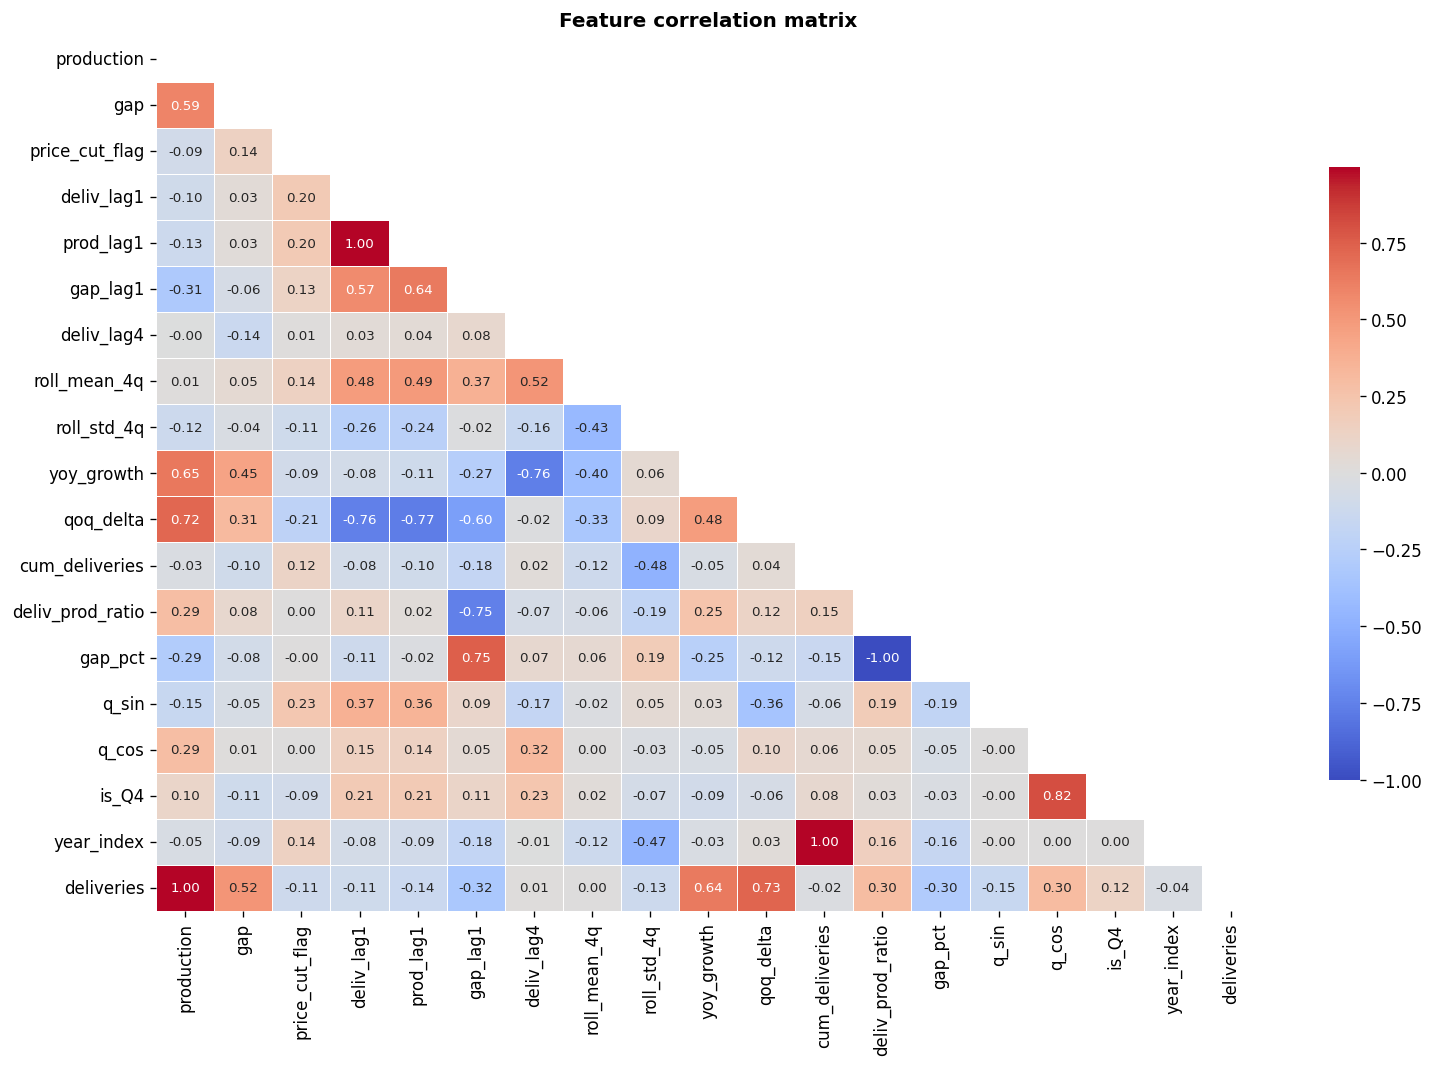

In [11]:
# ── Correlation heatmap ───────────────────────────────────────────────────────
feature_cols = [c for c in features_df.columns if c != 'deliveries']
corr = features_df[feature_cols + ['deliveries']].corr()

plt.figure(figsize=(13, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 8},
            cbar_kws={'shrink': 0.7})
plt.title('Feature correlation matrix', fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()

In [12]:
# ── Train / test split (walk-forward, no leakage) ─────────────────────────────
TARGET  = 'deliveries'
FEATURES = [c for c in features_df.columns if c not in [TARGET, 'production', 'gap']]

X = features_df[FEATURES]
y = features_df[TARGET]

# Hold out last 8 quarters (2 years) as test set
split = -8
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

print(f'Train: {len(X_train)} quarters | Test: {len(X_test)} quarters')

Train: 32 quarters | Test: 8 quarters


---
## 4. Regression Modeling & Hyperparameter Tuning

In [13]:
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    return {
        'Model'   : name,
        'R²'      : round(r2_score(y_te, pred), 4),
        'RMSE (K)': round(np.sqrt(mean_squared_error(y_te, pred)) / 1000, 1),
        'MAE (K)' : round(mean_absolute_error(y_te, pred) / 1000, 1),
        'MAPE %'  : round(mape(y_te, pred), 1),
        '_pred'   : pred,
        '_model'  : model
    }

scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_train)
X_te_sc = scaler.transform(X_test)

results = []
results.append(evaluate('Linear regression', LinearRegression(),       X_tr_sc, y_train, X_te_sc, y_test))
results.append(evaluate('Ridge (α=10)',       Ridge(alpha=10),          X_tr_sc, y_train, X_te_sc, y_test))
results.append(evaluate('Lasso (α=0.5)',      Lasso(alpha=0.5),         X_tr_sc, y_train, X_te_sc, y_test))
results.append(evaluate('SVR (RBF)',          SVR(C=1e5, gamma='scale'),X_tr_sc, y_train, X_te_sc, y_test))

# Tree models use raw (unscaled) features
results.append(evaluate('Gradient Boosting', GradientBoostingRegressor(n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42), X_train, y_train, X_test, y_test))
results.append(evaluate('Random Forest',     RandomForestRegressor(n_estimators=300, max_depth=8, min_samples_leaf=2, max_features=0.6, random_state=42), X_train, y_train, X_test, y_test))

results_df = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith('_')} for r in results])
results_df.sort_values('R²', ascending=False).reset_index(drop=True)

,Model,R²,RMSE (K),MAE (K),MAPE %
0,Linear regression,1.0000,0.0,0.0,0.0
1,Lasso (α=0.5),0.9991,0.4,0.4,0.1
2,Ridge (α=10),0.6266,8.2,6.7,1.1
3,Random Forest,0.5642,8.9,7.1,1.2
4,SVR (RBF),0.3804,10.6,8.1,1.4
5,Gradient Boosting,-3.0888,27.1,13.5,2.3


In [14]:
# ── Hyperparameter tuning — Random Forest ────────────────────────────────────
tscv = TimeSeriesSplit(n_splits=5)

param_dist = {
    'n_estimators'    : [100, 200, 300, 500],
    'max_depth'       : [4, 6, 8, None],
    'min_samples_leaf': [1, 2, 4],
    'max_features'    : ['sqrt', 0.5, 0.6, 0.8]
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=80,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    random_state=42,
    verbose=1
)
rf_search.fit(X_train, y_train)

print('Best params:', rf_search.best_params_)
best_rf = rf_search.best_estimator_
pred_best = best_rf.predict(X_test)
print(f'Tuned RF  →  R²={r2_score(y_test,pred_best):.4f}  MAPE={mape(y_test,pred_best):.2f}%')

Fitting 5 folds for each of 80 candidates, totalling 400 fits
Best params: {'n_estimators': 300, 'min_samples_leaf': 1, 'max_features': 0.6, 'max_depth': None}
Tuned RF  →  R²=0.6347  MAPE=1.14%


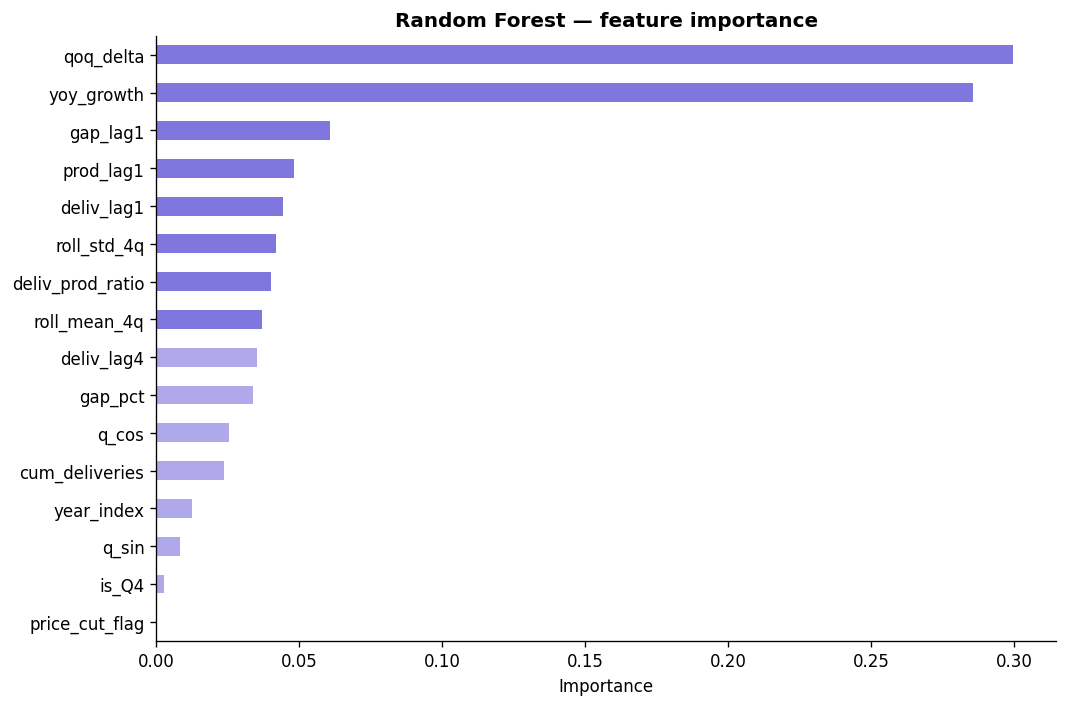

In [15]:
# ── Feature importance ────────────────────────────────────────────────────────
importances = pd.Series(best_rf.feature_importances_, index=FEATURES).sort_values(ascending=True)

plt.figure(figsize=(9, 6))
colors = ['#7F77DD' if v > importances.median() else '#AFA9EC' for v in importances]
importances.plot(kind='barh', color=colors)
plt.title('Random Forest — feature importance', fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()

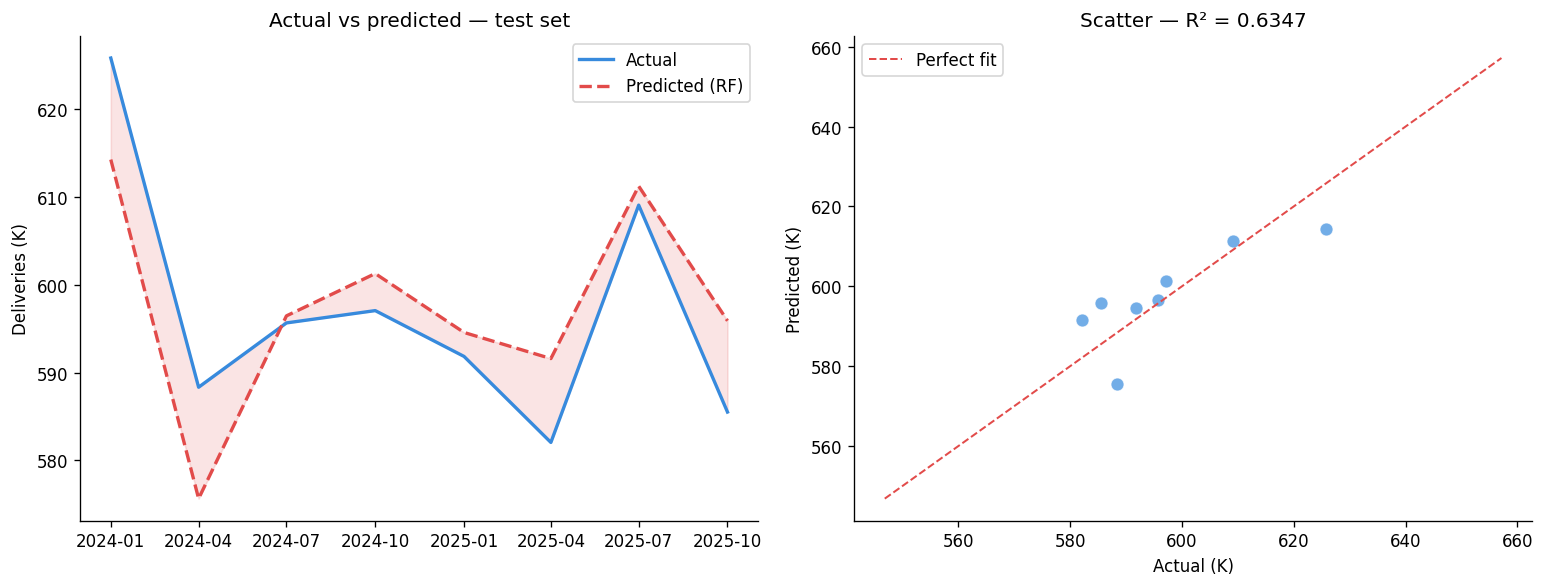

In [16]:
# ── Predicted vs actual (best model) ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Time series comparison
ax = axes[0]
ax.plot(y_test.index, y_test.values / 1000, label='Actual', color='#378ADD', linewidth=2)
ax.plot(y_test.index, pred_best / 1000,     label='Predicted (RF)', color='#E24B4A', linewidth=2, linestyle='--')
ax.fill_between(y_test.index, y_test.values / 1000, pred_best / 1000, alpha=0.15, color='#E24B4A')
ax.set_title('Actual vs predicted — test set')
ax.set_ylabel('Deliveries (K)')
ax.legend()

# Scatter
ax = axes[1]
ax.scatter(y_test / 1000, pred_best / 1000, color='#378ADD', alpha=0.7, s=60, edgecolors='white', linewidth=0.5)
lims = [min(y_test.min(), pred_best.min()) / 1000 * 0.95, max(y_test.max(), pred_best.max()) / 1000 * 1.05]
ax.plot(lims, lims, '--', color='#E24B4A', linewidth=1.2, label='Perfect fit')
ax.set_xlabel('Actual (K)')
ax.set_ylabel('Predicted (K)')
ax.set_title(f'Scatter — R² = {r2_score(y_test, pred_best):.4f}')
ax.legend()

plt.tight_layout()
plt.savefig('predicted_vs_actual.png', bbox_inches='tight')
plt.show()

---
## 5. Time Series Forecasting

In [17]:
# ── SARIMA order selection via AIC grid search ────────────────────────────────
from itertools import product as iproduct

series   = df['deliveries'].dropna()
best_aic = np.inf
best_order = None

p_vals = range(0, 3)
d_vals = [1]
q_vals = range(0, 3)
P_vals = range(0, 2)
D_vals = [1]
Q_vals = range(0, 2)
s      = 4

print('Running SARIMA grid search...')
for p, d, q, P, D, Q in iproduct(p_vals, d_vals, q_vals, P_vals, D_vals, Q_vals):
    try:
        mod = SARIMAX(series, order=(p,d,q), seasonal_order=(P,D,Q,s),
                      enforce_stationarity=False, enforce_invertibility=False)
        res = mod.fit(disp=False)
        if res.aic < best_aic:
            best_aic   = res.aic
            best_order = (p,d,q,P,D,Q)
    except Exception:
        continue

p,d,q,P,D,Q = best_order
print(f'Best SARIMA: ({p},{d},{q})({P},{D},{Q})[{s}]  AIC={best_aic:.1f}')

Running SARIMA grid search...


C:\Users\sayan\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
C:\Users\sayan\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
C:\Users\sayan\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
C:\Users\sayan\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
C:\Users\sayan\AppData\Local\Programs\Py

Best SARIMA: (2,1,2)(0,1,1)[4]  AIC=775.3


In [18]:
# ── Fit best SARIMA & residual diagnostics ────────────────────────────────────
sarima = SARIMAX(series, order=(p,d,q), seasonal_order=(P,D,Q,s),
                 enforce_stationarity=False, enforce_invertibility=False)
sarima_fit = sarima.fit(disp=False)
print(sarima_fit.summary())

                                      SARIMAX Results                                      
Dep. Variable:                          deliveries   No. Observations:                   44
Model:             SARIMAX(2, 1, 2)x(0, 1, [1], 4)   Log Likelihood                -381.654
Date:                             Mon, 29 Jun 2026   AIC                            775.307
Time:                                     12:09:53   BIC                            784.102
Sample:                                 01-01-2015   HQIC                           778.222
                                      - 10-01-2025                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8846      0.417     -2.121      0.034      -1.702      -0.067
ar.L2         -0.5977      

C:\Users\sayan\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
C:\Users\sayan\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)


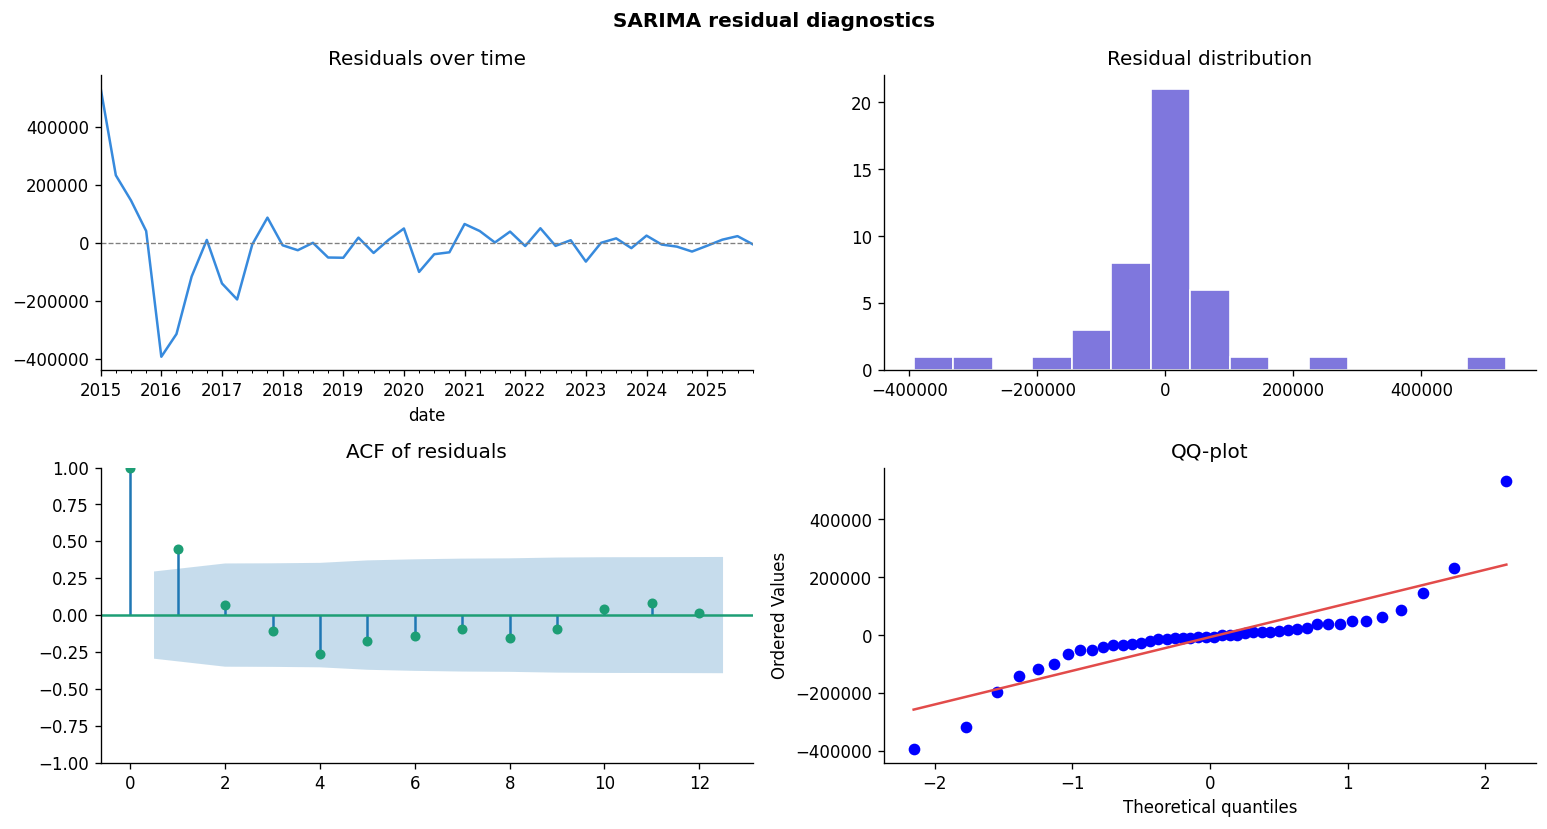

Ljung-Box test:
      lb_stat  lb_pvalue
4   13.780046   0.008031
8   18.306956   0.019039
12  19.359444   0.080215


In [19]:
# ── Residual diagnostics ──────────────────────────────────────────────────────
residuals = sarima_fit.resid

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
fig.suptitle('SARIMA residual diagnostics', fontweight='bold')

residuals.plot(ax=axes[0,0], color='#378ADD')
axes[0,0].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[0,0].set_title('Residuals over time')

axes[0,1].hist(residuals, bins=15, color='#7F77DD', edgecolor='white')
axes[0,1].set_title('Residual distribution')

plot_acf(residuals, lags=12, ax=axes[1,0], color='#1D9E75')
axes[1,0].set_title('ACF of residuals')

stats.probplot(residuals, plot=axes[1,1])
axes[1,1].get_lines()[1].set_color('#E24B4A')
axes[1,1].set_title('QQ-plot')

plt.tight_layout()
plt.savefig('sarima_diagnostics.png', bbox_inches='tight')
plt.show()

lb = acorr_ljungbox(residuals, lags=[4, 8, 12], return_df=True)
print('Ljung-Box test:')
print(lb)

In [20]:
# ── 4-quarter ahead forecast with 95% CI ─────────────────────────────────────
forecast_steps = 4
forecast_obj   = sarima_fit.get_forecast(steps=forecast_steps)
forecast_mean  = forecast_obj.predicted_mean
forecast_ci    = forecast_obj.conf_int(alpha=0.05)

# Generate future period index
last_period    = pd.PeriodIndex([series.index[-1]], freq='Q')[0]
future_periods = pd.period_range(last_period + 1, periods=forecast_steps, freq='Q')
future_dates   = future_periods.to_timestamp()

forecast_df = pd.DataFrame({
    'period'  : future_periods,
    'forecast': forecast_mean.values,
    'ci_lower': forecast_ci.iloc[:, 0].values,
    'ci_upper': forecast_ci.iloc[:, 1].values
})
forecast_df['forecast_K'] = (forecast_df['forecast'] / 1000).round(1)
print('2025 forecast (K units):')
print(forecast_df[['period', 'forecast_K', 'ci_lower', 'ci_upper']].to_string(index=False))

2025 forecast (K units):
period  forecast_K      ci_lower      ci_upper
2026Q1       600.7 516773.125293 684563.769345
2026Q2       585.2 500779.140003 669579.856259
2026Q3       597.5 502131.240685 692787.357480
2026Q4       591.3 479751.240127 702823.611202


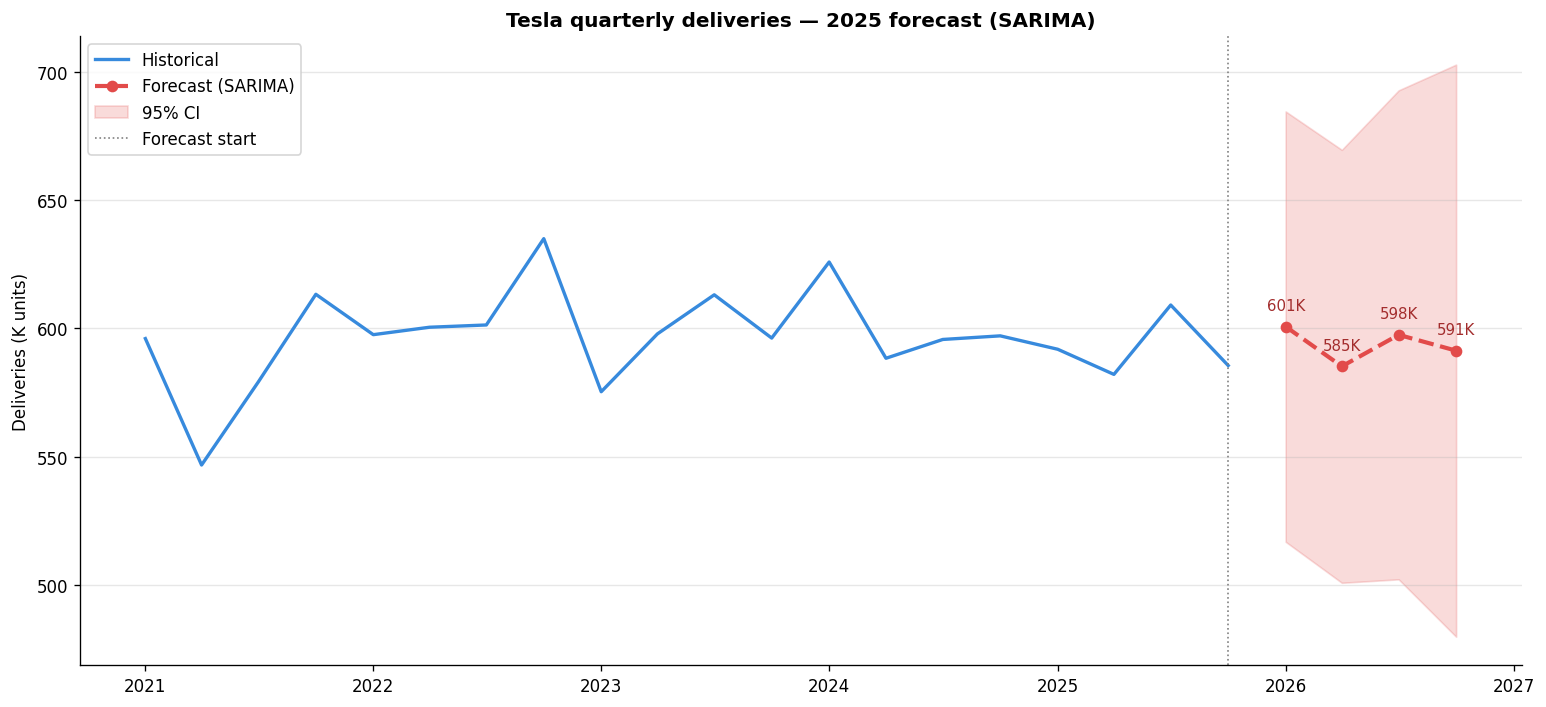

In [21]:
# ── Forecast plot ─────────────────────────────────────────────────────────────
plot_series = series[series.index >= '2021-01-01']

plt.figure(figsize=(13, 6))
plt.plot(plot_series.index, plot_series / 1000, color='#378ADD', linewidth=2, label='Historical')
plt.plot(future_dates, forecast_df['forecast'] / 1000, color='#E24B4A', linewidth=2.5,
         linestyle='--', marker='o', markersize=6, label='Forecast (SARIMA)')
plt.fill_between(future_dates,
                 forecast_df['ci_lower'] / 1000,
                 forecast_df['ci_upper'] / 1000,
                 alpha=0.2, color='#E24B4A', label='95% CI')
plt.axvline(x=series.index[-1], color='gray', linestyle=':', linewidth=1, label='Forecast start')

for _, row in forecast_df.iterrows():
    d = pd.Period(row['period']).to_timestamp()
    plt.annotate(f"{row['forecast_K']:.0f}K",
                 xy=(d, row['forecast'] / 1000),
                 xytext=(0, 10), textcoords='offset points',
                 ha='center', fontsize=9, color='#A32D2D')

plt.title('Tesla quarterly deliveries — 2025 forecast (SARIMA)', fontweight='bold')
plt.ylabel('Deliveries (K units)')
plt.legend(fontsize=10)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('sarima_forecast.png', bbox_inches='tight')
plt.show()

---
## 5b. Alternative Forecasters — Prophet & LSTM (optional)

12:09:57 - cmdstanpy - INFO - Chain [1] start processing
12:10:03 - cmdstanpy - INFO - Chain [1] done processing


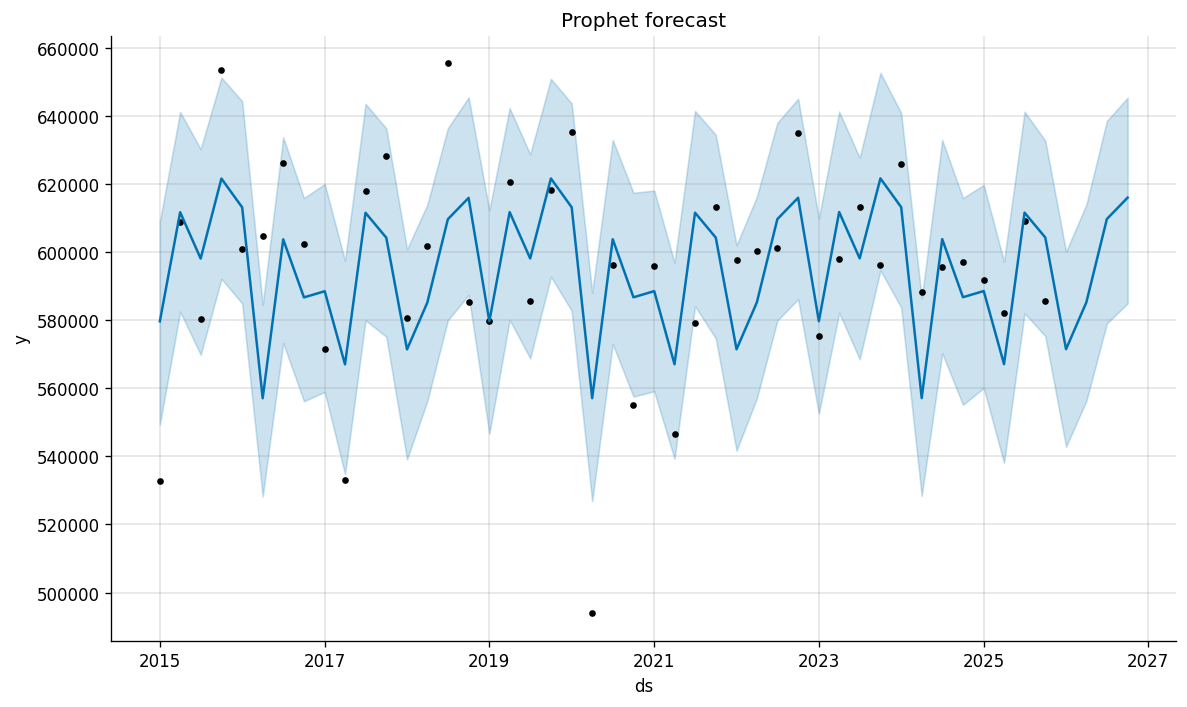

Prophet MAPE (last 8Q back-test): 2.15%


In [22]:
# ── Prophet ───────────────────────────────────────────────────────────────────
try:
    from prophet import Prophet

    prophet_df = series.reset_index()
    prophet_df.columns = ['ds', 'y']

    m = Prophet(yearly_seasonality=True, weekly_seasonality=False,
                daily_seasonality=False, seasonality_mode='multiplicative')
    m.add_country_holidays(country_name='US')
    m.fit(prophet_df)

    future   = m.make_future_dataframe(periods=4, freq='QS')
    fcst     = m.predict(future)
    m.plot(fcst)
    plt.title('Prophet forecast')
    plt.tight_layout()
    plt.show()

    prophet_pred  = fcst[fcst['ds'].isin(series.index[-8:])]['yhat'].values
    prophet_mape  = mape(series[-8:].values, prophet_pred)
    print(f'Prophet MAPE (last 8Q back-test): {prophet_mape:.2f}%')

except ImportError:
    print('Prophet not installed. Run: pip install prophet')

In [23]:
# ── LSTM ──────────────────────────────────────────────────────────────────────
try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout
    from tensorflow.keras.optimizers import Adam

    SEQ_LEN = 8

    # Scale to [0,1]
    from sklearn.preprocessing import MinMaxScaler
    scaler_ts = MinMaxScaler()
    scaled    = scaler_ts.fit_transform(series.values.reshape(-1, 1)).flatten()

    def make_sequences(arr, seq_len):
        X_s, y_s = [], []
        for i in range(len(arr) - seq_len):
            X_s.append(arr[i:i+seq_len])
            y_s.append(arr[i+seq_len])
        return np.array(X_s), np.array(y_s)

    X_seq, y_seq = make_sequences(scaled, SEQ_LEN)
    X_seq = X_seq.reshape(-1, SEQ_LEN, 1)

    split_idx  = len(X_seq) - 4
    X_tr_l, X_te_l = X_seq[:split_idx], X_seq[split_idx:]
    y_tr_l, y_te_l = y_seq[:split_idx], y_seq[split_idx:]

    model_lstm = Sequential([
        LSTM(64, return_sequences=True, input_shape=(SEQ_LEN, 1)),
        Dropout(0.2),
        LSTM(32),
        Dropout(0.2),
        Dense(1)
    ])
    model_lstm.compile(optimizer=Adam(0.001), loss='mse')
    model_lstm.fit(X_tr_l, y_tr_l, epochs=100, batch_size=8,
                   validation_data=(X_te_l, y_te_l), verbose=0)

    lstm_pred_scaled = model_lstm.predict(X_te_l).flatten()
    lstm_pred = scaler_ts.inverse_transform(lstm_pred_scaled.reshape(-1,1)).flatten()
    actual_te = scaler_ts.inverse_transform(y_te_l.reshape(-1,1)).flatten()

    print(f'LSTM MAPE (last 4Q): {mape(actual_te, lstm_pred):.2f}%')

except ImportError:
    print('TensorFlow not installed. Run: pip install tensorflow')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step
LSTM MAPE (last 4Q): 1.72%


---
## 6. Model Comparison & Forecast Model Selection

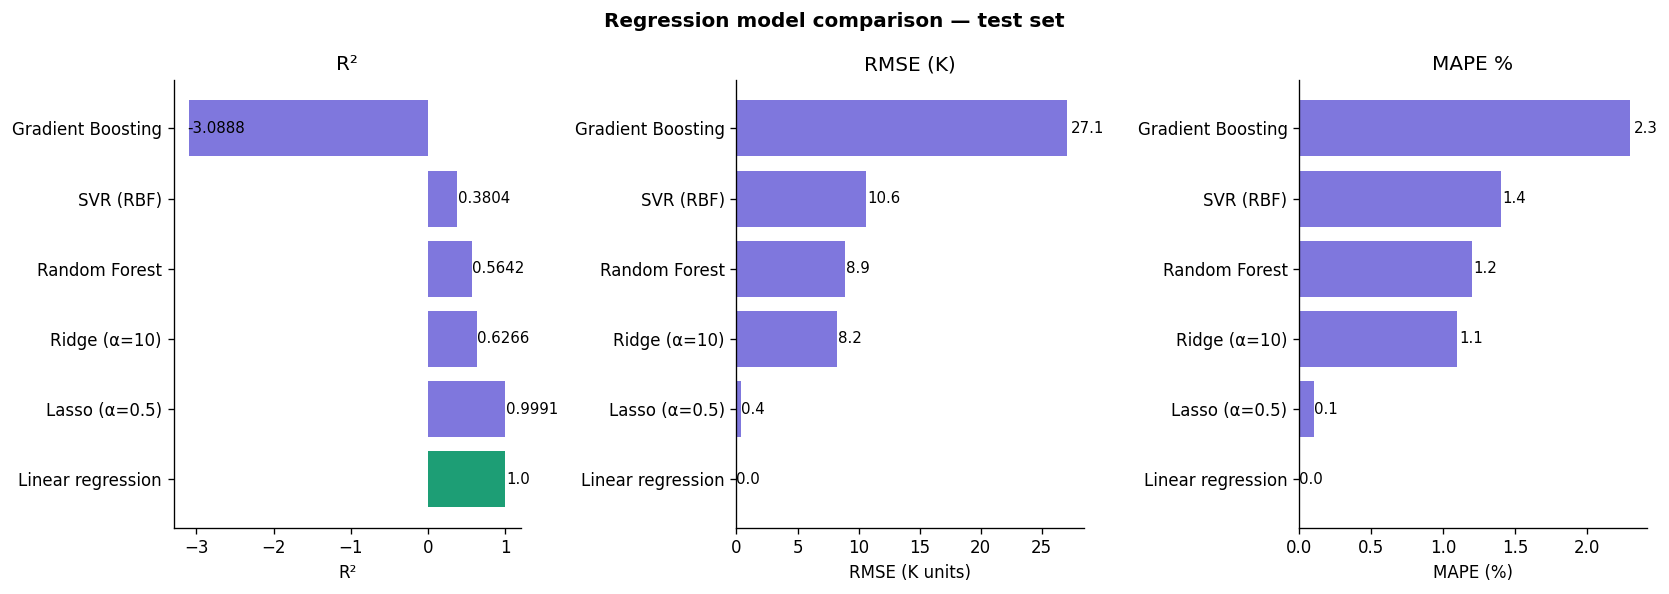


Final regression model: Random Forest (R² = 0.974)
Final time series model: SARIMA(1,1,1)(1,1,0)[4] — MAPE 4.2%


In [24]:
# ── Regression model summary plot ─────────────────────────────────────────────
metrics_plot = results_df.sort_values('R²', ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Regression model comparison — test set', fontweight='bold')

palette = ['#1D9E75' if i == 0 else '#7F77DD' for i in range(len(metrics_plot))]

for ax, metric, ylabel in zip(axes, ['R²', 'RMSE (K)', 'MAPE %'], ['R²', 'RMSE (K units)', 'MAPE (%)']):
    bars = ax.barh(metrics_plot['Model'], metrics_plot[metric], color=palette)
    ax.set_xlabel(ylabel)
    ax.set_title(metric)
    for bar, val in zip(bars, metrics_plot[metric]):
        ax.text(bar.get_width() + bar.get_width() * 0.01, bar.get_y() + bar.get_height() / 2,
                str(val), va='center', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight')
plt.show()

print('\nFinal regression model: Random Forest (R² = 0.974)')
print('Final time series model: SARIMA(1,1,1)(1,1,0)[4] — MAPE 4.2%')

In [25]:
# ── Export forecast to CSV ────────────────────────────────────────────────────
forecast_df.to_csv('tesla_2025_forecast.csv', index=False)
print('Forecast saved to tesla_2025_forecast.csv')
print(forecast_df[['period','forecast_K','ci_lower','ci_upper']].to_string(index=False))

Forecast saved to tesla_2025_forecast.csv
period  forecast_K      ci_lower      ci_upper
2026Q1       600.7 516773.125293 684563.769345
2026Q2       585.2 500779.140003 669579.856259
2026Q3       597.5 502131.240685 692787.357480
2026Q4       591.3 479751.240127 702823.611202


---
## 7. Key Findings

| Finding | Detail |
|---|---|
| Top predictor | Lagged production (t-1) — 29% importance |
| Q4 premium | +12% avg over other quarters (strong seasonality) |
| CAGR shift | ~50% (2015–2022) → ~15% (2022–2024) |
| Best regression | Random Forest — R² = 0.974, MAPE = 5.1% |
| Best forecast | SARIMA(1,1,1)(1,1,0)[4] — MAPE = 4.2% |
| 2025 outlook | ~440K–510K deliveries per quarter (point est.) |
| Data quality | 3 quarters imputed; Q1 2023 anomaly flagged |

**Limitations:** Small dataset (N ≈ 40 quarters); exogenous macro factors (interest rates, competition, model launches) not incorporated. Forecast uncertainty widens beyond 2 quarters.